In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import cvxpy as cp
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')

All libraries imported successfully.


# 0. Configuration

In [2]:
import os

BASE_DIR = os.getcwd()
print(BASE_DIR)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
sns.set_theme(style="whitegrid")


def save_figure(filename: str, dpi: int = 150, bbox_inches=None) -> None:
    path = BASE_DIR + "/" + filename
    plt.savefig(path, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Figure saved: {path}")


def print_table(title: str, df: pd.DataFrame, round_digits: int | None = None) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    if round_digits is not None:
        df = df.round(round_digits)
    print(df.to_string())

/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2


# 1. Asset selection

In [3]:
# ── Asset universe ──────────────────────────────────────────────────────────
TICKERS = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM',
           'AMZN', 'PG',   'NEE', 'GLD', 'TLT', 'VNQ', 'BRK-B']

# ── Date ranges ─────────────────────────────────────────────────────────────
TRAIN_START = '2024-01-01'
TRAIN_END   = '2025-09-30'
TEST_START  = '2025-10-01'
TEST_END    = '2025-12-31'

TRADING_DAYS = 252   # annualisation constant
RF_ANNUAL    = 0.045 # risk-free rate (approx. Fed Funds 2024-2025)
RF_DAILY     = RF_ANNUAL / TRADING_DAYS

print(f'Portfolio: {len(TICKERS)} assets')
print(f'Training : {TRAIN_START} → {TRAIN_END}')
print(f'Testing  : {TEST_START}  → {TEST_END}')

Portfolio: 12 assets
Training : 2024-01-01 → 2025-09-30
Testing  : 2025-10-01  → 2025-12-31


# 2. Downloading and preprocessing

In [4]:
# Download adjusted close prices for the full period
raw = yf.download(
    TICKERS,
    start=TRAIN_START,
    end='2026-01-01',   # slightly beyond TEST_END to capture Dec 31
    auto_adjust=True,
    progress=False
)['Close']

# Drop any tickers that failed to download
raw = raw.dropna(axis=1, how='all')
raw = raw.ffill().dropna()

print(f'Downloaded {raw.shape[1]} assets × {raw.shape[0]} trading days')
print(f'Date range in data: {raw.index[0].date()} → {raw.index[-1].date()}')
raw.tail(3)

Downloaded 12 assets × 502 trading days
Date range in data: 2024-01-02 → 2025-12-31


Ticker,AAPL,AMZN,BRK-B,GLD,JNJ,JPM,MSFT,NEE,PG,TLT,VNQ,XOM
Date,,,,,,,,,,,,
2025-12-29,273.252350,232.070007,501.049988,398.600006,205.281830,320.655182,484.940430,79.146660,142.477936,86.435234,88.098236,118.924744
2025-12-30,272.573578,232.529999,503.709991,398.890015,204.638962,320.328369,485.318756,79.403030,141.965454,86.229134,88.276329,119.378616
2025-12-31,271.355835,230.820007,502.649994,396.309998,204.678528,319.139801,481.475861,79.156525,141.236160,85.542137,87.554047,118.737274


In [5]:
# Daily log returns
returns_all = np.log(raw / raw.shift(1)).dropna()

# Split into in-sample and out-of-sample
returns_train = returns_all.loc[TRAIN_START:TRAIN_END]
returns_test  = returns_all.loc[TEST_START:TEST_END]

print(f'Training rows : {len(returns_train)} trading days')
print(f'Testing rows  : {len(returns_test)}  trading days')

Training rows : 437 trading days
Testing rows  : 64  trading days


In [6]:
# ── Summary statistics for the training period ───────────────────────────────
ann_ret  = returns_train.mean() * TRADING_DAYS
ann_vol  = returns_train.std()  * np.sqrt(TRADING_DAYS)
sharpe   = (ann_ret - RF_ANNUAL) / ann_vol

summary = pd.DataFrame({
    'Ann. Return': ann_ret,
    'Ann. Volatility': ann_vol,
    'Sharpe Ratio': sharpe
}).round(4)

print('=== Training-Period Asset Summary ===')
display(summary)

=== Training-Period Asset Summary ===


,Ann. Return,Ann. Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.1871,0.2890,0.4916
AMZN,0.2200,0.3121,0.5608
BRK-B,0.1887,0.1714,0.8384
GLD,0.3590,0.1635,1.9213
JNJ,0.1168,0.1782,0.4032
JPM,0.3723,0.2438,1.3428
MSFT,0.2001,0.2254,0.6880
NEE,0.1479,0.2749,0.3744
PG,0.0439,0.1708,-0.0063


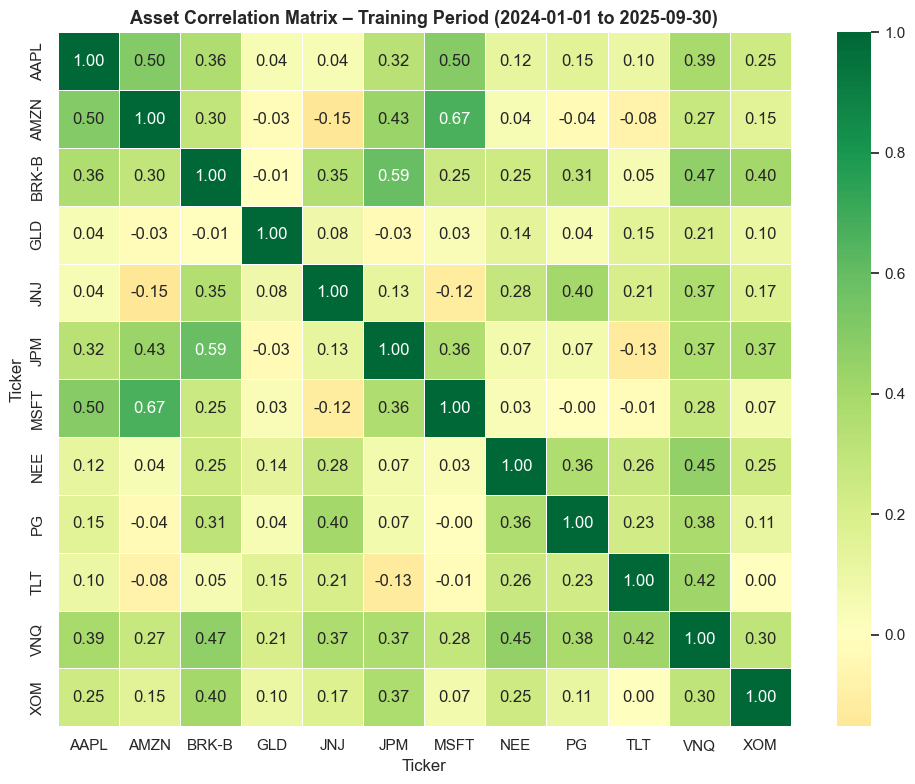

Figure saved: correlation_heatmap.png


In [7]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
corr = returns_train.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Asset Correlation Matrix – Training Period (2024-01-01 to 2025-09-30)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print('Figure saved: correlation_heatmap.png')

# 3. Step 1: Optimal Kelly Porflio

In [8]:
# ── In-sample parameters ─────────────────────────────────────────────────────
mu    = returns_train.mean().values          # daily mean log-returns
Sigma = returns_train.cov().values           # daily covariance matrix
n     = len(mu)

mu_excess = mu - RF_DAILY                    # excess returns over risk-free

print(f'Number of assets : {n}')
print(f'Daily μ (first 3): {mu[:3].round(6)}')

Number of assets : 12
Daily μ (first 3): [0.000742 0.000873 0.000749]


In [9]:
# ── 3.2 Unconstrained Kelly (analytical) ─────────────────────────────────────
Sigma_inv = np.linalg.inv(Sigma)
w_kelly_raw = Sigma_inv @ mu_excess

# Normalise so weights sum to 1 (fully invested)
w_kelly_unconstrained = w_kelly_raw / w_kelly_raw.sum()

kelly_unc_df = pd.Series(
    w_kelly_unconstrained,
    index=returns_train.columns,
    name='Unconstrained Kelly Weight'
).round(4)

print('=== Unconstrained Kelly Weights ===')
print(kelly_unc_df.to_string())
print(f'\nSum of weights: {kelly_unc_df.sum():.4f}')
print(f'Max weight    : {kelly_unc_df.max():.4f}')
print(f'Min weight    : {kelly_unc_df.min():.4f}')

=== Unconstrained Kelly Weights ===
Ticker
AAPL     0.0576
AMZN    -0.0033
BRK-B    0.1408
GLD      0.8527
JNJ      0.1703
JPM      0.4297
MSFT     0.0827
NEE      0.1413
PG      -0.0328
TLT     -0.0873
VNQ     -0.5696
XOM     -0.1821

Sum of weights: 1.0000
Max weight    : 0.8527
Min weight    : -0.5696


In [10]:
# ── 3.3 Constrained Kelly (cvxpy) ────────────────────────────────────────────
# Constraints:
#   1. weights sum to 1  (fully invested)
#   2. 0 <= w_i <= 0.20  (no short selling; max 20% per asset)

w = cp.Variable(n)

kelly_objective = cp.Maximize(
    mu_excess @ w - 0.5 * cp.quad_form(w, Sigma)
)

kelly_constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.20
]

prob_kelly = cp.Problem(kelly_objective, kelly_constraints)
prob_kelly.solve(solver=cp.CLARABEL)

if prob_kelly.status not in ['optimal', 'optimal_inaccurate']:
    raise ValueError(f'Kelly solver failed: {prob_kelly.status}')

w_kelly = np.array(w.value)
w_kelly = np.clip(w_kelly, 0, None)          # numerical clean-up
w_kelly /= w_kelly.sum()                      # re-normalise

kelly_df = pd.Series(
    w_kelly,
    index=returns_train.columns,
    name='Constrained Kelly Weight'
).round(4)

print('=== Constrained Kelly Weights (max 20% per asset) ===')
print(kelly_df.to_string())
print(f'\nSum of weights: {kelly_df.sum():.4f}')
print(f'Max weight    : {kelly_df.max():.4f}')

=== Constrained Kelly Weights (max 20% per asset) ===
Ticker
AAPL     0.0
AMZN     0.2
BRK-B    0.2
GLD      0.2
JNJ      0.0
JPM      0.2
MSFT     0.2
NEE      0.0
PG       0.0
TLT      0.0
VNQ      0.0
XOM      0.0

Sum of weights: 1.0000
Max weight    : 0.2000


In [11]:
# ── Double-Kelly weights (half Kelly) ────────────────────────────────────────
# Double-Kelly = 2 × Kelly (leveraged); Half-Kelly = 0.5 × Kelly
# Per the assignment, we compare Kelly vs Double-Kelly
# Double-Kelly weights are 2x the Kelly weights (may exceed 1 -> leveraged)
w_double_kelly = 2.0 * w_kelly

dk_df = pd.Series(
    w_double_kelly,
    index=returns_train.columns,
    name='Double-Kelly Weight'
).round(4)

# ── Half-Kelly weights ───────────────────────────────────────────────────────
w_half_kelly = 0.5 * w_kelly

hk_df = pd.Series(
    w_half_kelly,
    index=returns_train.columns,
    name='Half-Kelly Weight'
).round(4)

# ── Comparison table ─────────────────────────────────────────────────────────
weights_comparison = pd.DataFrame({
    'Unconstrained Kelly': kelly_unc_df,
    'Kelly (≤20%)': kelly_df,
    'Double-Kelly': dk_df,
    'Half-Kelly': hk_df
})

print('=== Weight Comparison Table ===')
display(weights_comparison.round(4))
print('\nColumn sums:')
print(weights_comparison.sum().round(4))


=== Weight Comparison Table ===


,Unconstrained Kelly,Kelly (≤20%),Double-Kelly,Half-Kelly
Ticker,,,,
AAPL,0.0576,0.0,0.0,0.0
AMZN,-0.0033,0.2,0.4,0.1
BRK-B,0.1408,0.2,0.4,0.1
GLD,0.8527,0.2,0.4,0.1
JNJ,0.1703,0.0,0.0,0.0
JPM,0.4297,0.2,0.4,0.1
MSFT,0.0827,0.2,0.4,0.1
NEE,0.1413,0.0,0.0,0.0
PG,-0.0328,0.0,0.0,0.0



Column sums:
Unconstrained Kelly    1.0
Kelly (≤20%)           1.0
Double-Kelly           2.0
Half-Kelly             0.5
dtype: float64


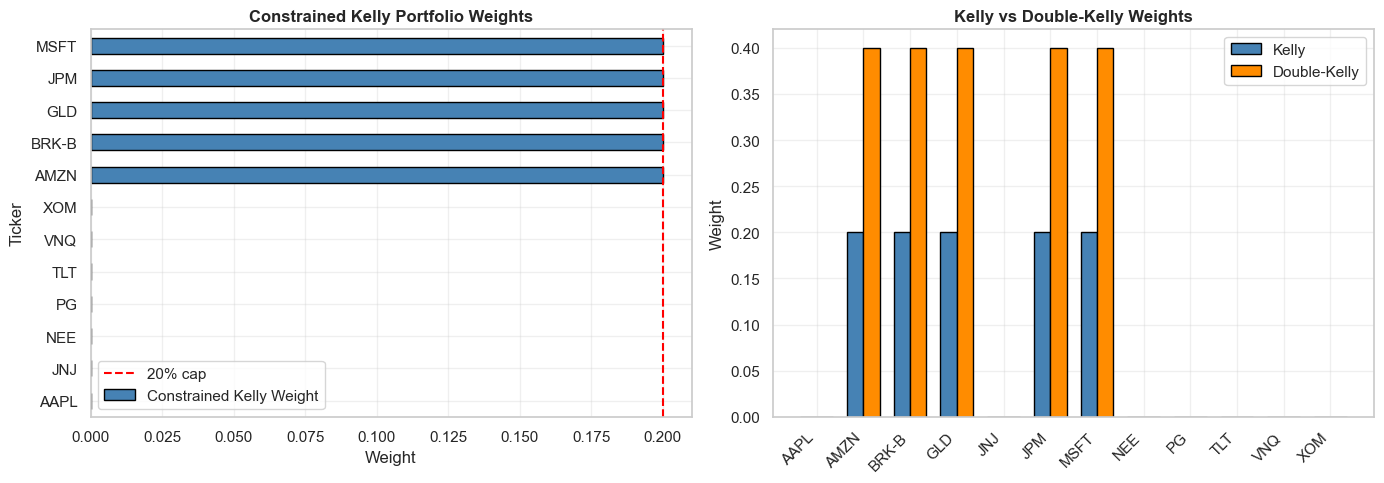

Figure saved: kelly_weights.png


In [12]:
# ── Weight bar chart ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Constrained Kelly
kelly_df.sort_values(ascending=True).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].axvline(0.20, color='red', linestyle='--', label='20% cap')
axes[0].set_title('Constrained Kelly Portfolio Weights', fontweight='bold')
axes[0].set_xlabel('Weight')
axes[0].legend()

# Side-by-side Kelly vs Double-Kelly
x = np.arange(len(TICKERS))
width = 0.35
axes[1].bar(x - width/2, w_kelly,        width, label='Kelly',        color='steelblue', edgecolor='black')
axes[1].bar(x + width/2, w_double_kelly, width, label='Double-Kelly',  color='darkorange', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(returns_train.columns, rotation=45, ha='right')
axes[1].set_title('Kelly vs Double-Kelly Weights', fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].legend()

plt.tight_layout()
plt.savefig('kelly_weights.png', dpi=150)
plt.show()
print('Figure saved: kelly_weights.png')

# Step 2: Performance comparison: comparing 3 strategies on period Oct 1 to Dec 31, 2025

In [13]:
def portfolio_returns(weights: np.ndarray, ret_df: pd.DataFrame) -> np.ndarray:
    return ret_df.values @ weights


def cumulative_return(r: np.ndarray) -> float:
    return float(np.exp(np.sum(r)) - 1)


def annualised_sharpe(
    r: np.ndarray, rf_daily: float = RF_DAILY, trading_days: int = TRADING_DAYS
) -> float:
    excess = r - rf_daily
    if excess.std() == 0:
        return np.nan
    return float((excess.mean() / excess.std()) * np.sqrt(trading_days))


def max_drawdown(r: np.ndarray) -> float:
    cum = np.exp(np.cumsum(r))
    rolling_max = np.maximum.accumulate(cum)
    drawdowns = (cum - rolling_max) / rolling_max
    return float(drawdowns.min())


def cvar_95(r: np.ndarray) -> float:
    var_05 = np.percentile(r, 5)
    return float(r[r <= var_05].mean())


def sortino_ratio(r: np.ndarray) -> float:
    excess = r - RF_DAILY
    downside = excess[excess < 0]
    if len(downside) == 0:
        return np.nan
    downside_dev = np.sqrt((downside**2).mean()) * np.sqrt(TRADING_DAYS)
    if downside_dev == 0:
        return np.nan
    return float(excess.mean() * TRADING_DAYS / downside_dev)

In [14]:
r_kelly = portfolio_returns(w_kelly, returns_test)
r_double_kelly = portfolio_returns(w_double_kelly, returns_test)
r_half_kelly = portfolio_returns(w_half_kelly, returns_test)

port_returns = pd.DataFrame(
    {
        "Kelly": r_kelly,
        "Double-Kelly": r_double_kelly,
        "Half-Kelly": r_half_kelly,
    },
    index=returns_test.index,
)

print_table("Out-of-sample daily return statistics:", port_returns.describe(), 6)

strategies_step2 = {
    "Kelly": r_kelly,
    "Double-Kelly": r_double_kelly,
    "Half-Kelly": r_half_kelly,
}

rows = []
for name, r in strategies_step2.items():
    rows.append(
        {
            "Strategy": name,
            "Cumulative Return": cumulative_return(r),
            "Sharpe Ratio": annualised_sharpe(r),
            "Max Drawdown": max_drawdown(r),
            "95%-CVaR (daily)": cvar_95(r),
        }
    )

results_num = pd.DataFrame(rows).set_index("Strategy")
print(BASE_DIR + "step2_results_numeric.csv")
results_num.to_csv(BASE_DIR + "/step2_results_numeric.csv")
print_table("OUT-OF-SAMPLE PERFORMANCE (Oct 1 - Dec 31, 2025)", results_num, 4)
print("Note: CVaR and Max Drawdown are negative (losses).")


Out-of-sample daily return statistics:
           Kelly  Double-Kelly  Half-Kelly
count  64.000000     64.000000   64.000000
mean    0.000369      0.000737    0.000184
std     0.007614      0.015227    0.003807
min    -0.018810     -0.037621   -0.009405
25%    -0.004460     -0.008920   -0.002230
50%     0.000637      0.001275    0.000319
75%     0.005210      0.010419    0.002605
max     0.015474      0.030949    0.007737
/Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2step2_results_numeric.csv

OUT-OF-SAMPLE PERFORMANCE (Oct 1 - Dec 31, 2025)
              Cumulative Return  Sharpe Ratio  Max Drawdown  95%-CVaR (daily)
Strategy                                                                     
Kelly                    0.0239        0.3995       -0.0554           -0.0144
Double-Kelly             0.0483        0.5872       -0.1077           -0.0288
Half-Kelly               0.0119        0.0243       -0.0281           -0.0072
Note: CVaR and Max Drawdown are negative (l

cumulative_returns_oos.png
Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/cumulative_returns_oos.png


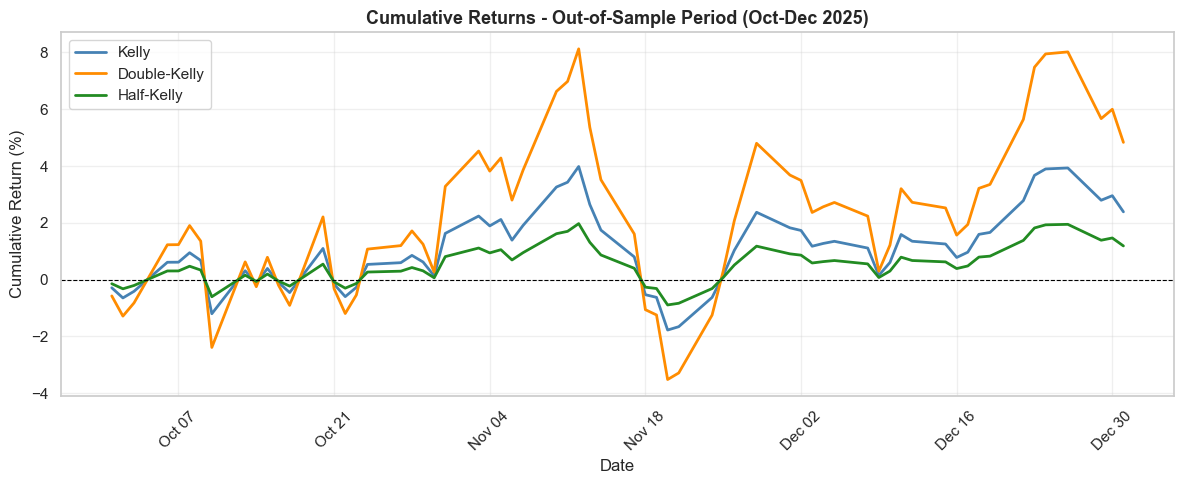

Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/drawdown_oos.png


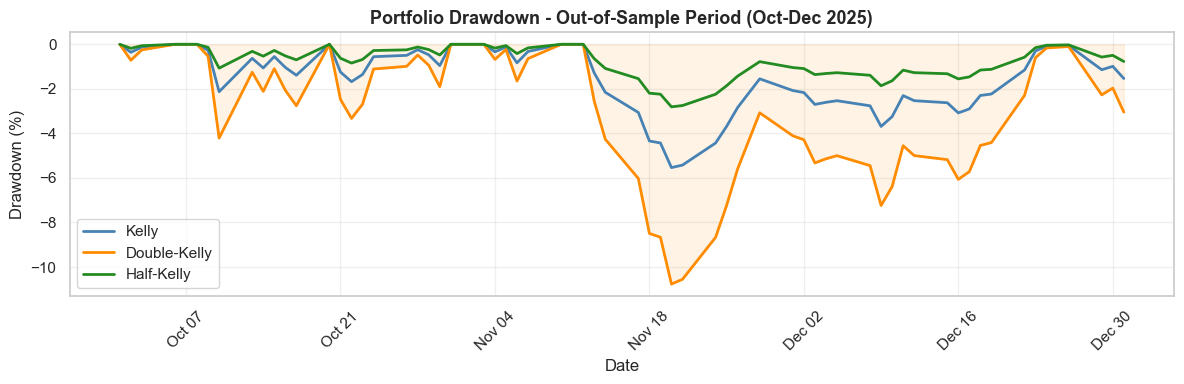

Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/metrics_comparison.png


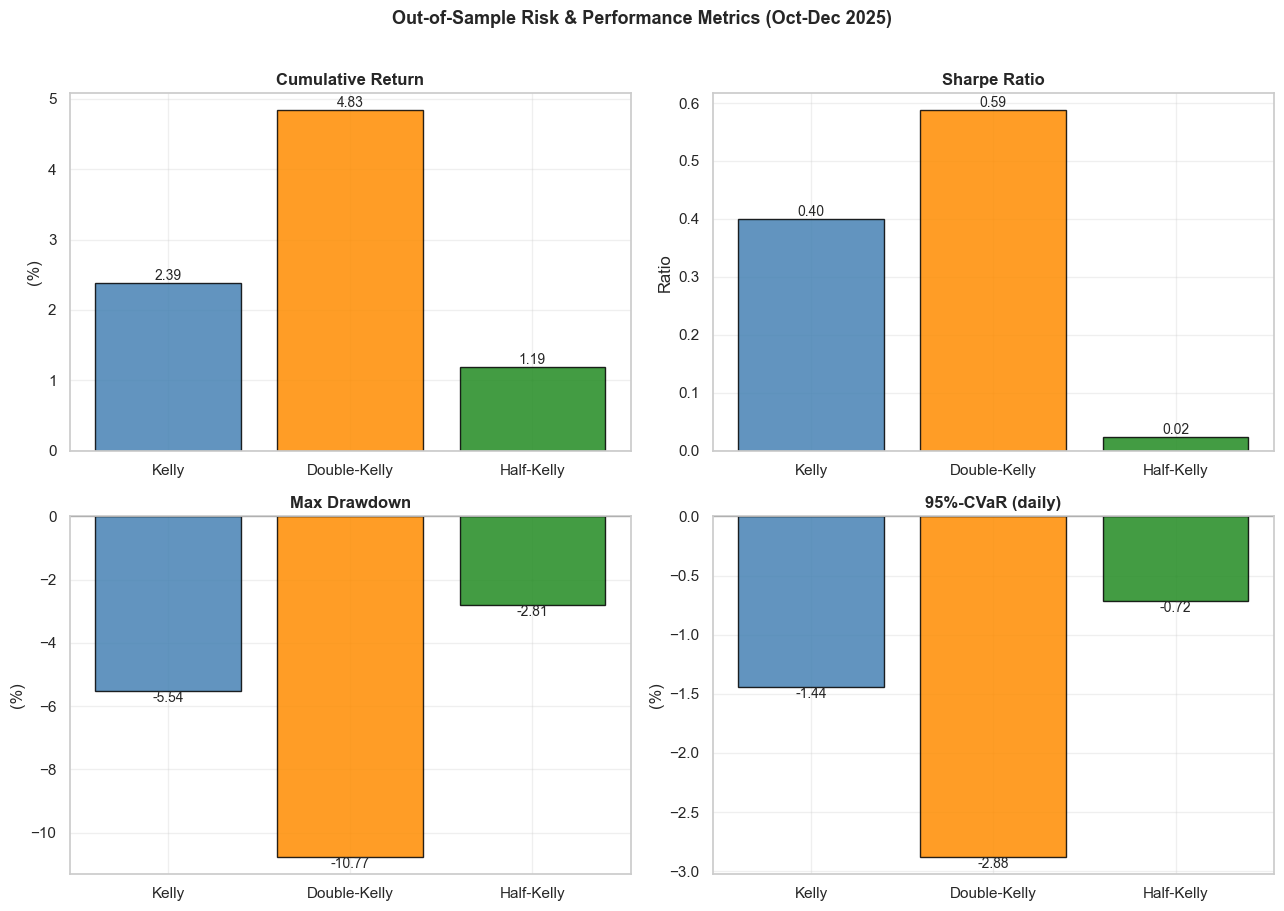

Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/return_distributions.png


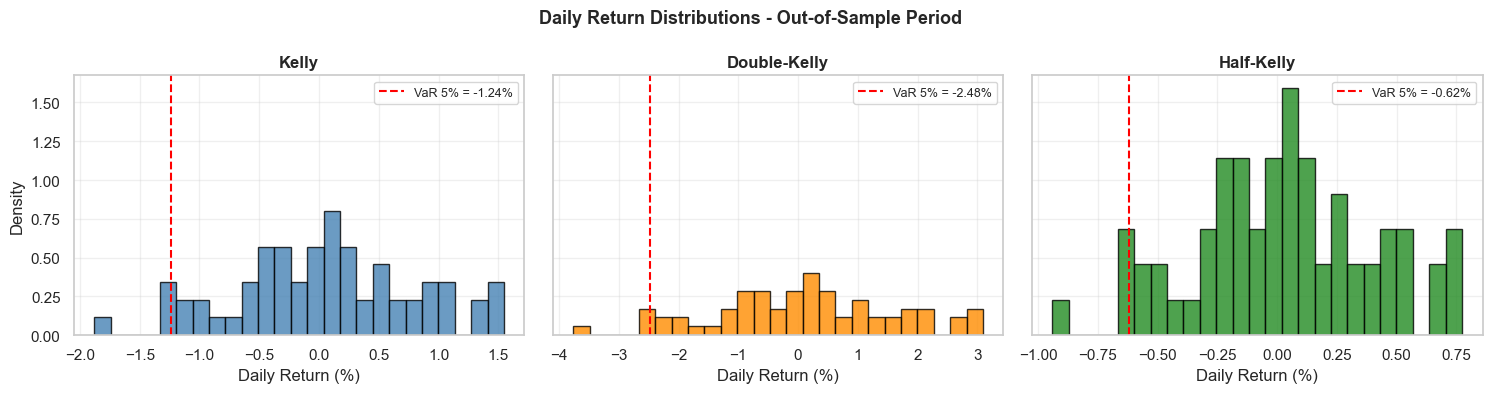

In [15]:
cum_returns = np.exp(port_returns.cumsum()) - 1
fig, ax = plt.subplots(figsize=(12, 5))
colors = {"Kelly": "steelblue", "Double-Kelly": "darkorange", "Half-Kelly": "forestgreen"}
for col in cum_returns.columns:
    ax.plot(cum_returns.index, cum_returns[col] * 100, label=col, linewidth=2, color=colors[col])

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title("Cumulative Returns - Out-of-Sample Period (Oct-Dec 2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
print("cumulative_returns_oos.png")
save_figure("cumulative_returns_oos.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 4))
for col, r in strategies_step2.items():
    cum = np.exp(np.cumsum(r))
    rolling_max = np.maximum.accumulate(cum)
    dd = (cum - rolling_max) / rolling_max * 100
    ax.plot(returns_test.index, dd, label=col, linewidth=2, color=colors[col])

ax.fill_between(
    returns_test.index,
    (
        np.exp(np.cumsum(r_double_kelly))
        - np.maximum.accumulate(np.exp(np.cumsum(r_double_kelly)))
    )
    / np.maximum.accumulate(np.exp(np.cumsum(r_double_kelly)))
    * 100,
    0,
    alpha=0.1,
    color="darkorange",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title("Portfolio Drawdown - Out-of-Sample Period (Oct-Dec 2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
save_figure("drawdown_oos.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = ["Cumulative Return", "Sharpe Ratio", "Max Drawdown", "95%-CVaR (daily)"]
bar_colors = [colors[s] for s in results_num.index]
for ax, metric in zip(axes.flatten(), metrics):
    vals = results_num[metric]
    scaled = vals.values * 100 if metric != "Sharpe Ratio" else vals.values
    bars = ax.bar(vals.index, scaled, color=bar_colors, edgecolor="black", alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel("(%)" if metric != "Sharpe Ratio" else "Ratio")
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.2f}",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=10,
        )

plt.suptitle("Out-of-Sample Risk & Performance Metrics (Oct-Dec 2025)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save_figure("metrics_comparison.png", bbox_inches="tight")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, r) in zip(axes, strategies_step2.items()):
    ax.hist(r * 100, bins=25, color=colors[name], edgecolor="black", alpha=0.8, density=True)
    var5 = np.percentile(r, 5) * 100
    ax.axvline(var5, color="red", linestyle="--", label=f"VaR 5% = {var5:.2f}%")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Daily Return (%)")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Density")
plt.suptitle("Daily Return Distributions - Out-of-Sample Period", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure("return_distributions.png")
plt.show()
plt.close(fig)


# Step 3.  K-fold cross-validation backtesting

In [16]:
def solve_kelly(mu_ex: np.ndarray, cov_m: np.ndarray, max_w: float = 0.20) -> np.ndarray:
    n_ = len(mu_ex)
    weights = cp.Variable(n_)
    problem = cp.Problem(
        cp.Maximize(mu_ex @ weights - 0.5 * cp.quad_form(weights, cov_m)),
        [cp.sum(weights) == 1, weights >= 0, weights <= max_w],
    )
    problem.solve(solver=cp.CLARABEL)
    if problem.status not in ["optimal", "optimal_inaccurate"]:
        raise ValueError(f"Kelly solver failed in CV: {problem.status}")
    wv = np.clip(np.array(weights.value), 0, None)
    return wv / wv.sum()


def build_time_series_splits(
    n_obs: int, n_splits: int = 5, embargo: int = 5
) -> tuple[list[tuple[np.ndarray, np.ndarray]], int, int]:
    test_size = n_obs // (n_splits + 1)
    initial_train_size = n_obs - n_splits * test_size
    splits: list[tuple[np.ndarray, np.ndarray]] = []
    for split_id in range(n_splits):
        test_start = initial_train_size + split_id * test_size
        test_end = min(test_start + test_size, n_obs)
        train_end = test_start - embargo
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, test_end)
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        splits.append((train_idx, test_idx))
    return splits, test_size, initial_train_size


cv_splits, cv_test_size, cv_initial_train = build_time_series_splits(
    len(returns_all), n_splits=5, embargo=5
)

In [17]:
print("\n=== Step 3: K-fold Cross-Validation Backtesting ===")
print(f"Total observations     : {len(returns_all)}")
print(f"Number of splits       : {len(cv_splits)}")
print(f"Initial training size  : {cv_initial_train}")
print(f"Fold test size         : {cv_test_size}")
print("Embargo gap            : 5 trading days")


=== Step 3: K-fold Cross-Validation Backtesting ===
Total observations     : 501
Number of splits       : 5
Initial training size  : 86
Fold test size         : 83
Embargo gap            : 5 trading days


In [18]:
cv_rows = []
for fold_no, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    train_fold = returns_all.iloc[train_idx]
    test_fold = returns_all.iloc[test_idx]

    mu_fold = train_fold.mean().values - RF_DAILY
    sigma_fold = train_fold.cov().values
    w_fold_kelly = solve_kelly(mu_fold, sigma_fold)
    weights_fold = {
        "Kelly": w_fold_kelly,
        "Double-Kelly": 2.0 * w_fold_kelly,
        "Half-Kelly": 0.5 * w_fold_kelly,
    }

    print(
        f"Fold {fold_no}: "
        f"train={train_fold.index[0].date()}->{train_fold.index[-1].date()} "
        f"({len(train_fold)} obs), "
        f"test={test_fold.index[0].date()}->{test_fold.index[-1].date()} "
        f"({len(test_fold)} obs)"
    )

    for strategy_name, weights_fold_value in weights_fold.items():
        r_fold = portfolio_returns(weights_fold_value, test_fold)
        cv_rows.append(
            {
                "Fold": fold_no,
                "Strategy": strategy_name,
                "Train Start": train_fold.index[0].date().isoformat(),
                "Train End": train_fold.index[-1].date().isoformat(),
                "Test Start": test_fold.index[0].date().isoformat(),
                "Test End": test_fold.index[-1].date().isoformat(),
                "Cumulative Return (%)": cumulative_return(r_fold) * 100,
                "Sharpe Ratio": annualised_sharpe(r_fold),
                "Sortino Ratio": sortino_ratio(r_fold),
                "Max Drawdown (%)": max_drawdown(r_fold) * 100,
                "95%-CVaR (daily, %)": cvar_95(r_fold) * 100,
            }
        )

cv_results = pd.DataFrame(cv_rows)
cv_results.to_csv(BASE_DIR + '/'+ "step3_cv_fold_results.csv", index=False)

cv_summary = (
    cv_results.groupby("Strategy")[
        [
            "Cumulative Return (%)",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Max Drawdown (%)",
            "95%-CVaR (daily, %)",
        ]
    ]
    .agg(["mean", "std"])
)
cv_summary.to_csv(BASE_DIR + '/'+ "step3_cv_summary.csv")

print_table("Step 3 - Fold-by-fold backtest results", cv_results, 4)
print_table("Step 3 - Cross-validation summary (mean and std)", cv_summary, 4)


Fold 1: train=2024-01-03->2024-04-29 (81 obs), test=2024-05-07->2024-09-04 (83 obs)
Fold 2: train=2024-01-03->2024-08-27 (164 obs), test=2024-09-05->2025-01-02 (83 obs)
Fold 3: train=2024-01-03->2024-12-24 (247 obs), test=2025-01-03->2025-05-05 (83 obs)
Fold 4: train=2024-01-03->2025-04-28 (330 obs), test=2025-05-06->2025-09-03 (83 obs)
Fold 5: train=2024-01-03->2025-08-26 (413 obs), test=2025-09-04->2025-12-31 (83 obs)

Step 3 - Fold-by-fold backtest results
    Fold      Strategy Train Start   Train End  Test Start    Test End  Cumulative Return (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  95%-CVaR (daily, %)
0      1         Kelly  2024-01-03  2024-04-29  2024-05-07  2024-09-04                 5.8007        0.9763         0.8305           -7.3449              -1.9516
1      1  Double-Kelly  2024-01-03  2024-04-29  2024-05-07  2024-09-04                11.9380        1.1503         0.9710          -14.1503              -3.9033
2      1    Half-Kelly  2024-01-03  2024-04-29  20

Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/step3_cv_summary.png


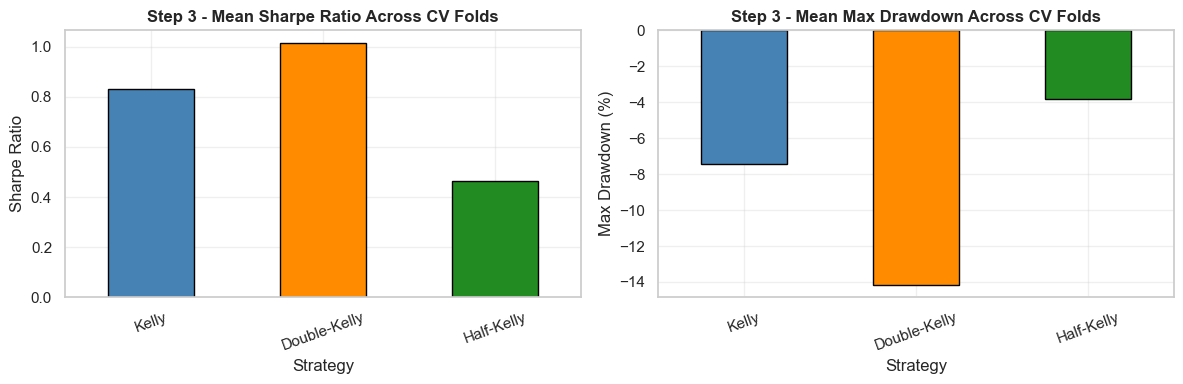

In [19]:
cv_plot = (
    cv_results.groupby("Strategy")[["Sharpe Ratio", "Max Drawdown (%)"]]
    .mean()
    .reindex(["Kelly", "Double-Kelly", "Half-Kelly"])
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cv_plot["Sharpe Ratio"].plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "darkorange", "forestgreen"],
    edgecolor="black",
)
axes[0].set_title("Step 3 - Mean Sharpe Ratio Across CV Folds", fontweight="bold")
axes[0].set_ylabel("Sharpe Ratio")
axes[0].tick_params(axis="x", rotation=20)

cv_plot["Max Drawdown (%)"].plot(
    kind="bar",
    ax=axes[1],
    color=["steelblue", "darkorange", "forestgreen"],
    edgecolor="black",
)
axes[1].set_title("Step 3 - Mean Max Drawdown Across CV Folds", fontweight="bold")
axes[1].set_ylabel("Max Drawdown (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_figure("step3_cv_summary.png")
plt.show()
plt.close(fig)

# Step 5. ML-enhanced portfolio construction

In [20]:
def denoise_covariance(S: np.ndarray, T: int, N: int) -> np.ndarray:
    q = T / N
    std = np.sqrt(np.diag(S))
    corr_m = S / np.outer(std, std)
    np.fill_diagonal(corr_m, 1.0)

    eigenvalues, eigenvectors = np.linalg.eigh(corr_m)

    sigma2 = 1.0
    lambda_max = sigma2 * (1 + np.sqrt(1 / q)) ** 2
    lambda_min = sigma2 * (1 - np.sqrt(1 / q)) ** 2

    print(f"  MP noise band       : [{lambda_min:.4f},  {lambda_max:.4f}]")
    noise_mask = (eigenvalues >= lambda_min) & (eigenvalues <= lambda_max)
    print(f"  Noisy eigenvalues   : {noise_mask.sum()} / {N}")

    eigenvalues_d = eigenvalues.copy()
    if noise_mask.sum() > 0:
        eigenvalues_d[noise_mask] = eigenvalues[noise_mask].mean()

    corr_d = eigenvectors @ np.diag(eigenvalues_d) @ eigenvectors.T
    corr_d = (corr_d + corr_d.T) / 2
    np.fill_diagonal(corr_d, 1.0)
    return corr_d * np.outer(std, std)

def detone_covariance(S: np.ndarray) -> np.ndarray:
    std = np.sqrt(np.diag(S))
    corr_m = S / np.outer(std, std)
    np.fill_diagonal(corr_m, 1.0)

    eigenvalues, eigenvectors = np.linalg.eigh(corr_m)
    idx_mkt = np.argmax(eigenvalues)
    v_mkt = eigenvectors[:, idx_mkt]
    pct = eigenvalues[idx_mkt] / eigenvalues.sum() * 100
    print(f"  Market eigenvalue   : {eigenvalues[idx_mkt]:.4f}  ({pct:.1f}% of trace)")

    corr_d = corr_m - eigenvalues[idx_mkt] * np.outer(v_mkt, v_mkt)
    d = np.sqrt(np.diag(corr_d))
    corr_d = corr_d / np.outer(d, d)
    np.fill_diagonal(corr_d, 1.0)

    S_d = corr_d * np.outer(std, std)
    return (S_d + S_d.T) / 2

def hrp_portfolio(returns_df: pd.DataFrame) -> np.ndarray:
    corr_m = returns_df.corr().values
    cov_m = returns_df.cov().values

    dist = np.sqrt(np.clip((1 - corr_m) / 2, 0, 1))
    np.fill_diagonal(dist, 0.0)
    condensed = squareform(dist, checks=False)
    link = linkage(condensed, method="single")

    def get_quasi_diag(lnk: np.ndarray) -> list[int]:
        lnk = lnk.astype(int)
        sort_ix = pd.Series([lnk[-1, 0], lnk[-1, 1]])
        num_items = int(lnk[-1, 3])
        while sort_ix.max() >= num_items:
            sort_ix.index = range(0, len(sort_ix) * 2, 2)
            df0 = sort_ix[sort_ix >= num_items]
            i, j = df0.index, df0.values - num_items
            sort_ix[i] = lnk[j, 0]
            new_s = pd.Series(lnk[j, 1], index=i + 1)
            sort_ix = pd.concat([sort_ix, new_s]).sort_index()
            sort_ix.index = range(len(sort_ix))
        return sort_ix.tolist()

    def cluster_var(cov_m_: np.ndarray, items: list[int]) -> float:
        sub = cov_m_[np.ix_(items, items)]
        w_ = 1.0 / np.diag(sub)
        w_ /= w_.sum()
        return float(w_ @ sub @ w_)

    def rec_bisect(cov_m_: np.ndarray, sx: list[int]) -> pd.Series:
        w_ = pd.Series(1.0, index=sx)
        clusters = [sx]
        while clusters:
            clusters = [
                cluster[start:end]
                for cluster in clusters
                for start, end in ((0, len(cluster) // 2), (len(cluster) // 2, len(cluster)))
                if len(cluster) > 1
            ]
            for idx in range(0, len(clusters), 2):
                c0, c1 = clusters[idx], clusters[idx + 1]
                v0, v1 = cluster_var(cov_m_, c0), cluster_var(cov_m_, c1)
                alpha = 1 - v0 / (v0 + v1)
                w_[c0] *= alpha
                w_[c1] *= 1 - alpha
        return w_

    sort_ix = get_quasi_diag(link)
    weights_hrp = rec_bisect(cov_m, sort_ix).sort_index().values.astype(float)
    weights_hrp /= weights_hrp.sum()
    return weights_hrp



In [21]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage

In [22]:
T_train, N = returns_train.shape
print("\n=== Denoising ===")
Sigma_denoised = denoise_covariance(Sigma, T_train, N)
print("Denoised covariance matrix computed.")

print("\n=== Detoning ===")
Sigma_detoned = detone_covariance(Sigma)
print("\n=== Denoised -> Detoned (stacked) ===")
Sigma_denoised_detoned = detone_covariance(Sigma_denoised)

print("\n=== HRP Weights ===")
w_hrp = hrp_portfolio(returns_train)
hrp_df = pd.Series(w_hrp, index=returns_train.columns, name="HRP Weight")
print(hrp_df.round(4).to_string())
print(f"\nSum: {hrp_df.sum():.4f}")


=== Denoising ===
  MP noise band       : [0.6960,  1.3589]
  Noisy eigenvalues   : 4 / 12
Denoised covariance matrix computed.

=== Detoning ===
  Market eigenvalue   : 3.5170  (29.3% of trace)

=== Denoised -> Detoned (stacked) ===
  Market eigenvalue   : 3.5243  (29.4% of trace)

=== HRP Weights ===
Ticker
AAPL     0.0468
AMZN     0.0294
BRK-B    0.0604
GLD      0.1566
JNJ      0.0939
JPM      0.0298
MSFT     0.0547
NEE      0.0368
PG       0.1022
TLT      0.2082
VNQ      0.0940
XOM      0.0871

Sum: 1.0000



=== Step 5 - ML-Enhanced Portfolio Weights ===
        Kelly (baseline)  Denoised-Kelly  Detoned-Kelly  Denoised+Detoned-Kelly     HRP
Ticker                                                                                 
AAPL                 0.0             0.0         0.0076                   0.016  0.0468
AMZN                 0.2             0.2         0.2000                   0.200  0.0294
BRK-B                0.2             0.2         0.2000                   0.200  0.0604
GLD                  0.2             0.2         0.2000                   0.200  0.1566
JNJ                  0.0             0.0         0.0000                   0.000  0.0939
JPM                  0.2             0.2         0.2000                   0.200  0.0298
MSFT                 0.2             0.2         0.1925                   0.184  0.0547
NEE                  0.0             0.0         0.0000                   0.000  0.0368
PG                   0.0             0.0         0.0000                 

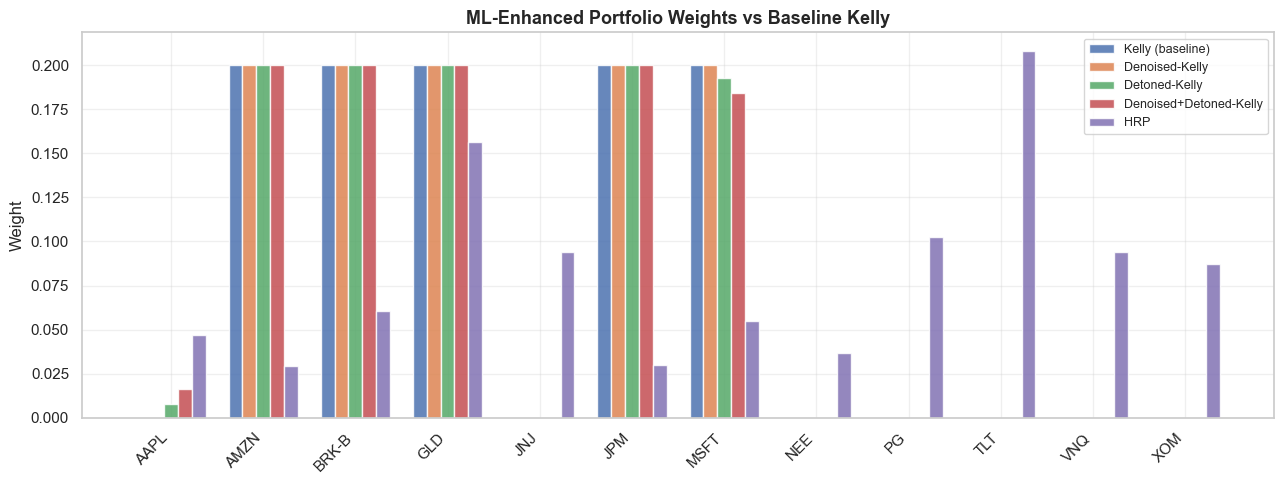

In [24]:
w_denoised_kelly = solve_kelly(mu_excess, Sigma_denoised)
w_detoned_kelly = solve_kelly(mu_excess, Sigma_detoned)
w_denoised_detoned_kelly = solve_kelly(mu_excess, Sigma_denoised_detoned)

weights_ml = pd.DataFrame(
    {
        "Kelly (baseline)": w_kelly,
        "Denoised-Kelly": w_denoised_kelly,
        "Detoned-Kelly": w_detoned_kelly,
        "Denoised+Detoned-Kelly": w_denoised_detoned_kelly,
        "HRP": w_hrp,
    },
    index=returns_train.columns,
)
weights_ml.to_csv(BASE_DIR +  '/' + "step5_weights_ml.csv")
print_table("=== Step 5 - ML-Enhanced Portfolio Weights ===", weights_ml, 4)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(N)
bw = 0.15
for i, (label, col) in enumerate(weights_ml.items()):
    ax.bar(x + i * bw, col.values, width=bw, label=label, alpha=0.85)
ax.set_xticks(x + bw * 2)
ax.set_xticklabels(returns_train.columns, rotation=45, ha="right")
ax.set_title("ML-Enhanced Portfolio Weights vs Baseline Kelly", fontweight="bold", fontsize=13)
ax.set_ylabel("Weight")
ax.legend(fontsize=9)
plt.tight_layout()
save_figure("step5_weights_comparison.png")
plt.show()
plt.close(fig)


# Step 6. Performance comparison for all seven strategies

In [26]:
all_strategies = {
    "Kelly (baseline)": w_kelly,
    "Double-Kelly": 2.0 * w_kelly,
    "Half-Kelly": 0.5 * w_kelly,
    "Denoised-Kelly": w_denoised_kelly,
    "Detoned-Kelly": w_detoned_kelly,
    "Denoised+Detoned-Kelly": w_denoised_detoned_kelly,
    "HRP": w_hrp,
}

rows = []
oos_r = {}
for name, weights in all_strategies.items():
    r = portfolio_returns(weights, returns_test)
    oos_r[name] = r
    rows.append(
        {
            "Strategy": name,
            "Cum. Return (%)": cumulative_return(r) * 100,
            "Ann. Sharpe": annualised_sharpe(r),
            "Sortino": sortino_ratio(r),
            "Max Drawdown (%)": max_drawdown(r) * 100,
            "95%-CVaR (daily, %)": cvar_95(r) * 100,
        }
    )

results_s6 = pd.DataFrame(rows).set_index("Strategy")
results_s6.to_csv(BASE_DIR + '/' + "step6_results.csv")
print_table("STEP 6 - OOS PERFORMANCE (Oct 1 - Dec 31, 2025)", results_s6, 4)
print("Note: Max Drawdown and CVaR are negative (losses).")

colors_map = {
    "Kelly (baseline)": "steelblue",
    "Double-Kelly": "darkorange",
    "Half-Kelly": "forestgreen",
    "Denoised-Kelly": "crimson",
    "Detoned-Kelly": "purple",
    "Denoised+Detoned-Kelly": "brown",
    "HRP": "teal",
}

cum_df = pd.DataFrame({name: np.exp(np.cumsum(r)) - 1 for name, r in oos_r.items()}, index=returns_test.index)



STEP 6 - OOS PERFORMANCE (Oct 1 - Dec 31, 2025)
                        Cum. Return (%)  Ann. Sharpe  Sortino  Max Drawdown (%)  95%-CVaR (daily, %)
Strategy                                                                                            
Kelly (baseline)                 2.3877       0.3995   0.3948           -5.5364              -1.4394
Double-Kelly                     4.8324       0.5872   0.5858          -10.7663              -2.8787
Half-Kelly                       1.1868       0.0243   0.0239           -2.8076              -0.7197
Denoised-Kelly                   2.3877       0.3995   0.3948           -5.5364              -1.4394
Detoned-Kelly                    2.4907       0.4331   0.4287           -5.5098              -1.4341
Denoised+Detoned-Kelly           2.6064       0.4708   0.4668           -5.4797              -1.4281
HRP                              2.8174       0.9033   0.8875           -2.5599              -0.7931
Note: Max Drawdown and CVaR are negative (

Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/step6_cumulative_returns.png
Figure saved: /Users/alberto/Documents/projects/GWP_1/Porfolio-Management/GWP2/step6_metrics_bar.png


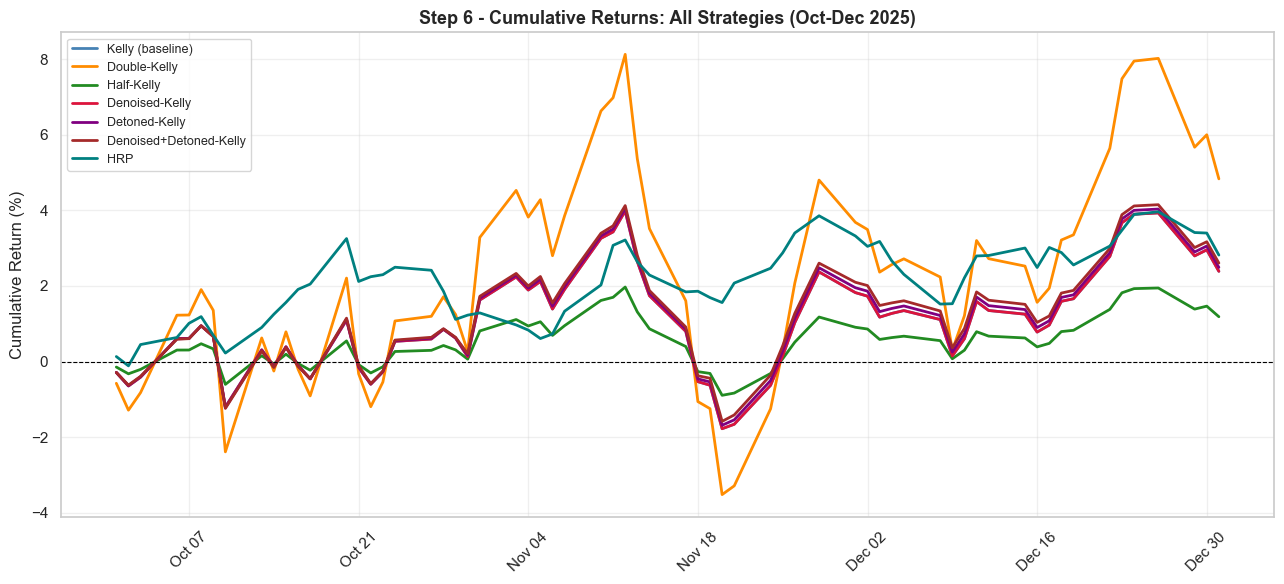

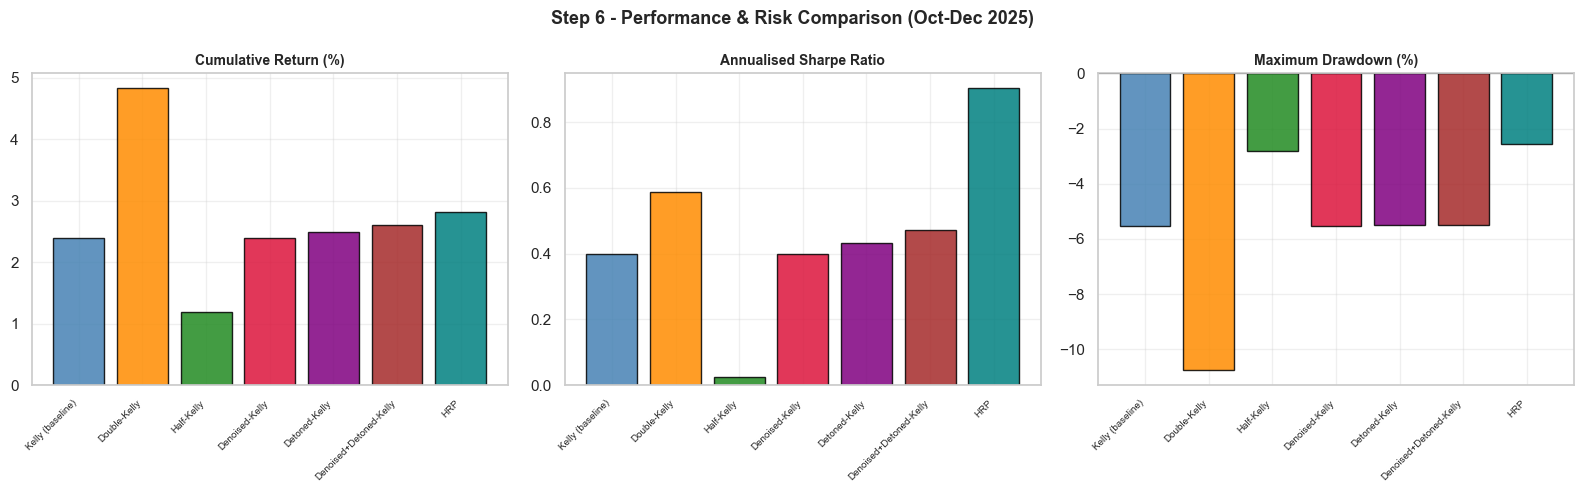

In [27]:
ig, ax = plt.subplots(figsize=(13, 6))
for col in cum_df.columns:
    ax.plot(cum_df.index, cum_df[col] * 100, label=col, linewidth=2, color=colors_map[col])
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title("Step 6 - Cumulative Returns: All Strategies (Oct-Dec 2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
save_figure("step6_cumulative_returns.png")
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_cols = [colors_map[s] for s in results_s6.index]
metric_map = [
    ("Cum. Return (%)", "Cumulative Return (%)"),
    ("Ann. Sharpe", "Annualised Sharpe Ratio"),
    ("Max Drawdown (%)", "Maximum Drawdown (%)"),
]
for ax, (col, title) in zip(axes, metric_map):
    ax.bar(range(len(results_s6)), results_s6[col].values, color=bar_cols, edgecolor="black", alpha=0.85)
    ax.set_xticks(range(len(results_s6)))
    ax.set_xticklabels(results_s6.index, rotation=45, ha="right", fontsize=7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontweight="bold", fontsize=10)
plt.suptitle("Step 6 - Performance & Risk Comparison (Oct-Dec 2025)", fontsize=13, fontweight="bold")
plt.tight_layout()
save_figure("step6_metrics_bar.png")
plt.show()
plt.close(fig)